CLASSIFICATION

In [15]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [16]:
don = pd.read_csv("donclassif.txt", header=0, sep=";")
don.head()
print(don.shape)
print(don.describe)

(2800, 2)
<bound method NDFrame.describe of             V1        V2
0     6.002504  0.031505
1     6.004021  0.063168
2     6.004545  0.094957
3     6.004069  0.126843
4     6.002587  0.158794
...        ...       ...
2795  1.223519  5.870877
2796 -0.472344  4.910527
2797  0.961090  5.183866
2798  0.067021  5.228207
2799  0.138501  4.122749

[2800 rows x 2 columns]>


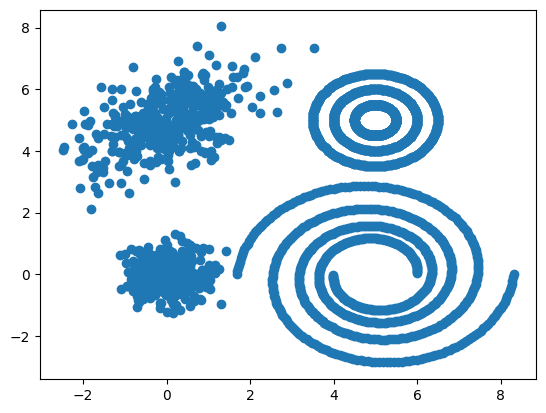

In [17]:
plt.plot(don["V1"],don["V2"],'o')
plt.show()

In [18]:
from sklearn.cluster import KMeans
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

3    738
4    660
1    553
5    451
0    213
2    185
Name: count, dtype: int64

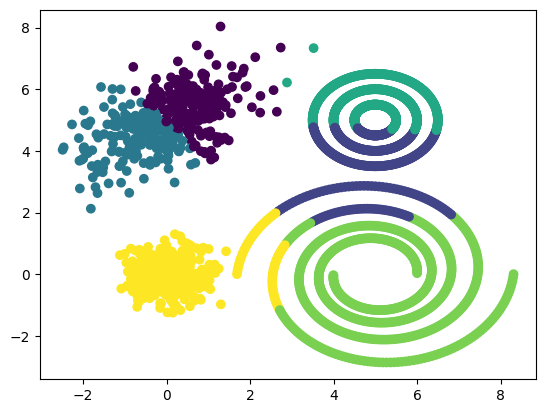

In [19]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

1    608
3    599
0    437
5    393
2    392
4    371
Name: count, dtype: int64


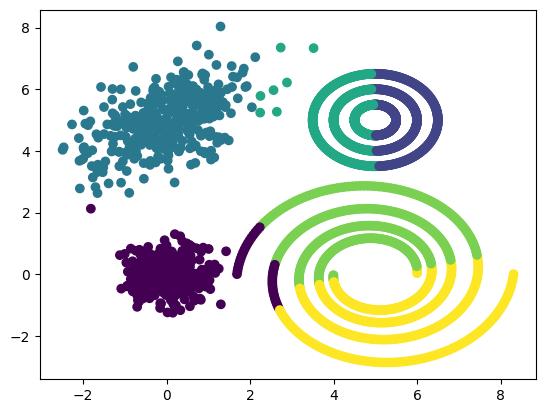

In [20]:
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
print(pd.Series(tmp.labels_).value_counts())
plt.show()

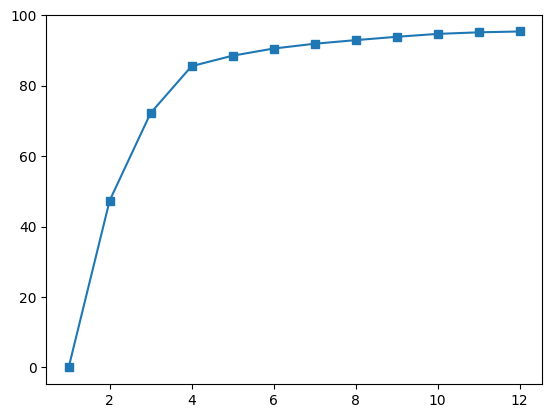

In [21]:
rapport = np.zeros(12)
inertietot = KMeans(n_clusters=1, n_init=10).fit(don)
inertietot = inertietot.inertia_
### car je ne sais pas retrouver l'inertie totale
for ii in range(1, 13):
    toto = KMeans(n_clusters=ii, n_init=10,init='random').fit(don)
    rapport[ii-1] = 100-round(toto.inertia_ / inertietot * 100, 2)
### je fais 100 moins pour avoir l'évolution croissante qui est à mon avis plus facile àlire
plt.plot(range(1, 13), rapport, marker='s')
plt.show()

je choisis 4 groupes

In [22]:
tmp = KMeans(n_clusters=4, n_init=100,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

3    1244
2     708
1     454
0     394
Name: count, dtype: int64

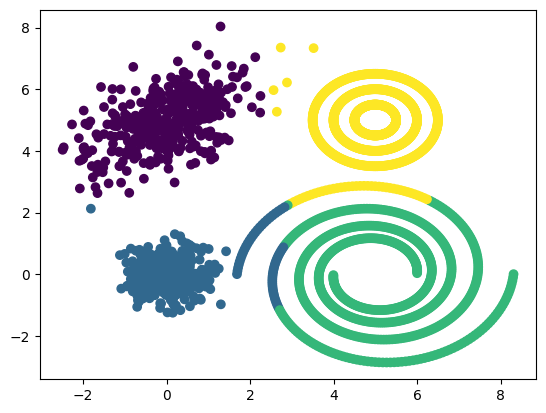

In [23]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

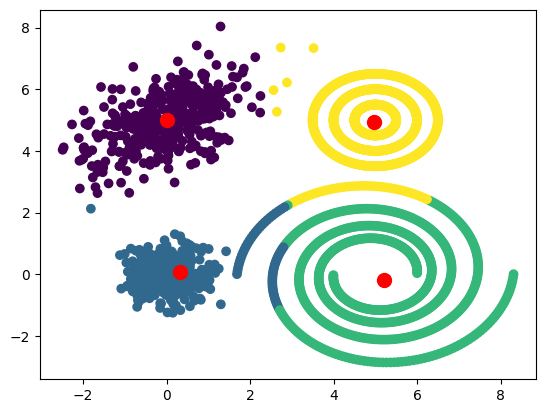

In [24]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.scatter(tmp.cluster_centers_[:,0],tmp.cluster_centers_[:,1], color="red", s=100)
plt.show()

ET classification hiérarchique

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

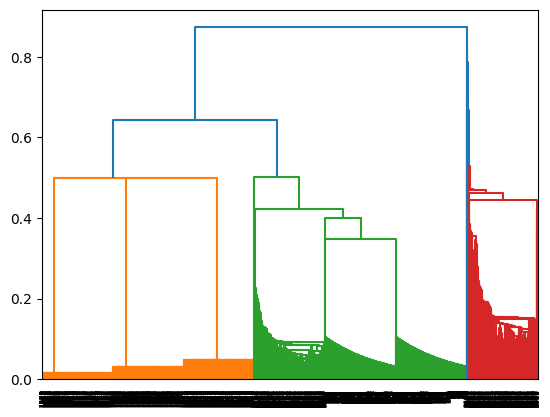

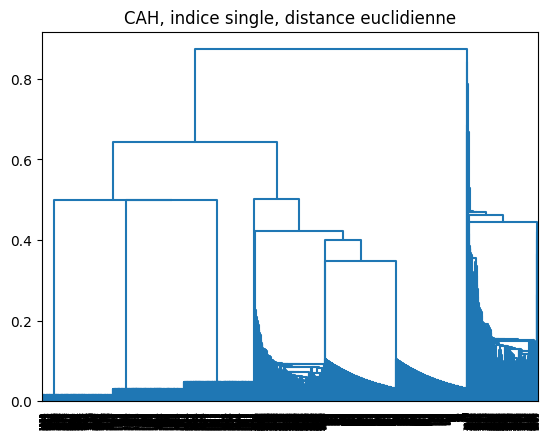

In [41]:
### choix du lien et de la distance
hiera_sim = linkage(don)
dendrogram(hiera_sim,labels=don.index)
plt.show()
hiera_sim = linkage(don,method="single")
plt.title("CAH, indice single, distance euclidienne")
dendrogram(hiera_sim,labels=don.index,color_threshold=0)
plt.show()

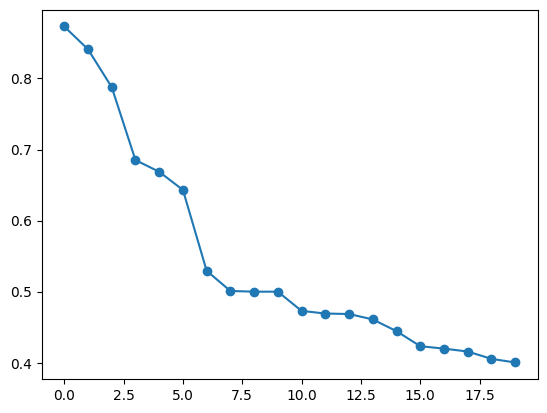

In [48]:
heights = np.sort(hiera_sim[:,2])[::-1]
plt.plot(heights[:20], marker="o")

In [59]:
labels10 = fcluster(hiera_sim,10, criterion="maxclust")
pd.Series(labels10).value_counts()

3     1199
2      800
1      400
5      395
4        1
6        1
9        1
10       1
7        1
8        1
Name: count, dtype: int64

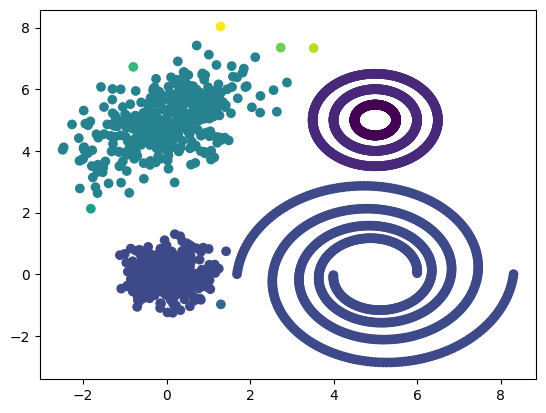

In [60]:
plt.scatter(don["V1"],don["V2"],c=labels10)
plt.show()

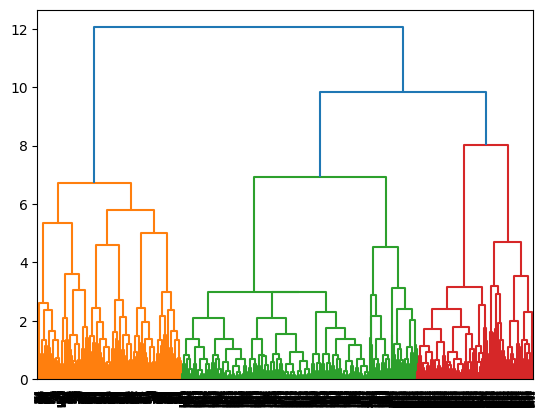

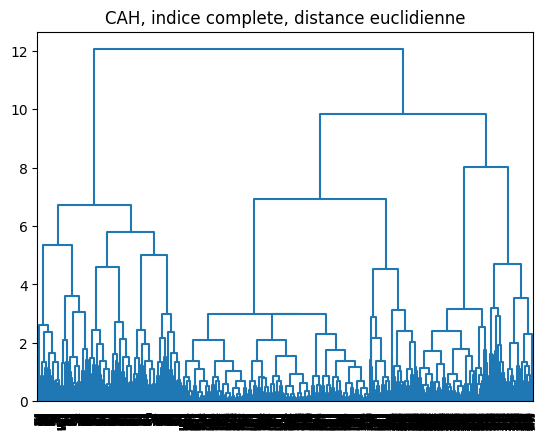

In [28]:
### choix du lien et de la distance
hiera_com = linkage(don,method='complete')
dendrogram(hiera_com,labels=don.index)
plt.show()

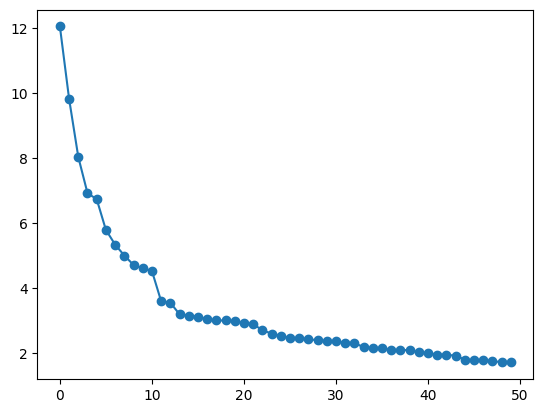

In [61]:
heights = np.sort(hiera_com[:,2])[::-1]
plt.plot(heights[:50], marker="o")

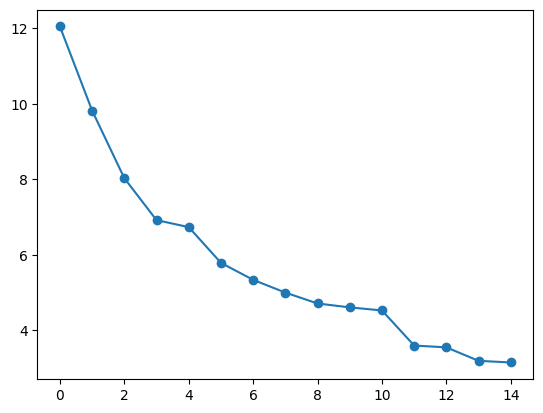

In [62]:
plt.plot(heights[:15], marker="o")

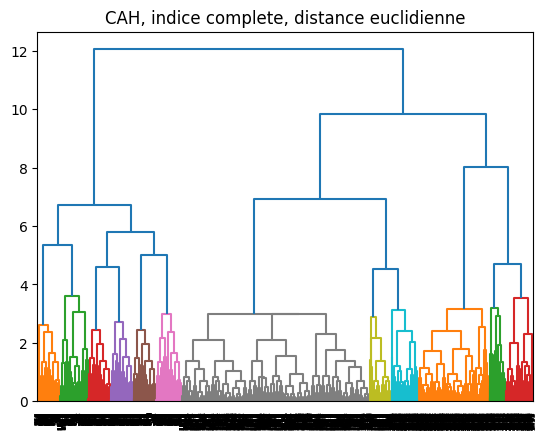

In [63]:
hauteur = heights[10]
plt.title("CAH, indice complete, distance euclidienne")
dendrogram(hiera_com,labels=don.index,color_threshold=hauteur)
plt.show()

In [39]:
labels10 = fcluster(hiera_com, 10, criterion="maxclust")
pd.Series(labels10).value_counts()

6     1064
8      408
7      264
3      256
2      160
10     154
5      144
4      128
1      128
9       94
Name: count, dtype: int64

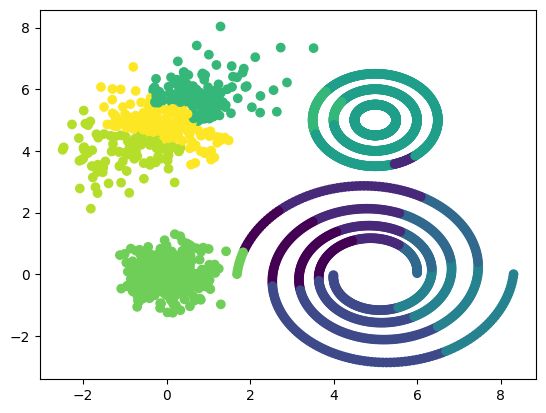

In [40]:
plt.scatter(don["V1"],don["V2"],c=labels10)
plt.show()